In [83]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix

In [84]:
# Loading data set 
df = pd.read_csv("shop_smart_ecommerce.csv")
df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


In [64]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [65]:
df.tail()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False
12329,0,0.0,0,0.0,3,21.250000,0.000000,0.066667,0.000000,0.0,Nov,3,2,1,2,New_Visitor,True,False


In [66]:
df.shape

(12330, 18)

In [67]:
df.sample(20)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
9141,0,0.000000,0,0.000000,27,892.967949,0.014815,0.022751,0.000000,0.0,Dec,2,2,3,2,Returning_Visitor,True,False
3353,0,0.000000,0,0.000000,12,312.666667,0.000000,0.033333,0.000000,0.0,May,1,1,1,4,Returning_Visitor,False,False
372,2,44.500000,0,0.000000,7,212.166667,0.000000,0.006250,0.000000,0.0,Mar,3,2,1,8,New_Visitor,True,False
703,0,0.000000,0,0.000000,6,551.000000,0.033333,0.050000,0.000000,0.0,Mar,1,1,3,1,Returning_Visitor,False,False
4064,0,0.000000,0,0.000000,19,337.166667,0.000000,0.003509,0.000000,1.0,May,1,1,9,3,Returning_Visitor,True,False
9522,0,0.000000,0,0.000000,91,2056.106981,0.008889,0.023937,0.000000,0.0,Nov,2,2,1,2,Returning_Visitor,True,False
11143,1,8.000000,1,47.500000,46,689.060606,0.002273,0.012063,1.125146,0.0,Nov,2,2,2,11,Returning_Visitor,True,True
6933,10,78.900000,0,0.000000,15,718.800000,0.000000,0.015789,0.000000,0.0,Nov,2,2,4,2,New_Visitor,False,False
5800,0,0.000000,0,0.000000,0,0.000000,0.180000,0.181818,0.000000,0.0,June,2,2,7,6,Returning_Visitor,False,False
6173,2,75.600000,2,652.800000,10,1143.666667,0.000000,0.023333,0.000000,0.0,Aug,2,2,4,2,Returning_Visitor,False,False


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [69]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


## EDA

Text(0.5, 1.0, 'Is Buy or Not')

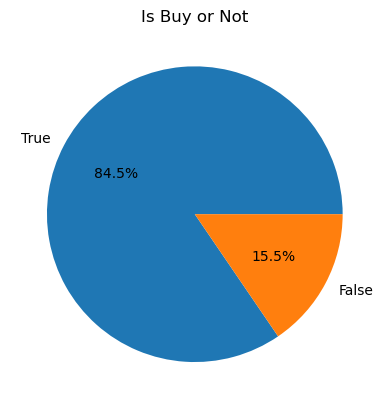

In [70]:
# checking how data is balanced ??
classes_count = df["Revenue"].value_counts()
plt.pie(classes_count , labels = ["True","False"],autopct = "%1.1f%%" )
plt.title("Is Buy or Not")

In [71]:
df.isnull().sum()  # no null values

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

## Duplicate Record

In [72]:
df.duplicated().sum() # 125 duplicate Rows in Dataset 

np.int64(125)

In [73]:
df.drop_duplicates(inplace=True)

## Target Variable Visualization

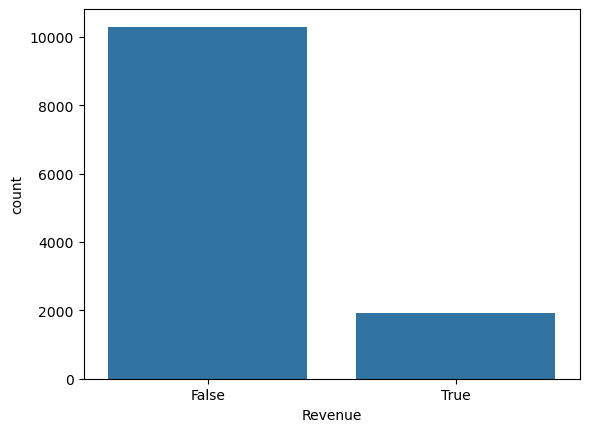

In [74]:
sns.countplot(x = "Revenue", data= df) # countplot(...) => This Tells Seaborn to automaticaly count how many times each unique value appers in a specific column and than plot those counts as bars 
plt.show()

## Categorical Features

In [75]:
df.select_dtypes(include = "object").columns

Index(['Month', 'VisitorType'], dtype='object')

## Label Encoding

In [76]:
le = LabelEncoder()

df["Month"] = le.fit_transform(df["Month"])

df["VisitorType"] = le.fit_transform(df["VisitorType"])

df["Weekend"] = df["Weekend"].astype(int)

df["Revenue"] = df["Revenue"].astype(int)

df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,2,1,1,1,1,2,0,0
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,2,2,2,1,2,2,0,0
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,2,4,1,9,3,2,0,0
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,2,3,2,2,4,2,0,0
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,2,3,3,1,4,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,1,4,6,1,1,2,1,0
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,7,3,2,1,8,2,1,0
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,7,3,2,1,13,2,1,0
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,7,2,2,3,11,2,0,0


## Correlation Analysis

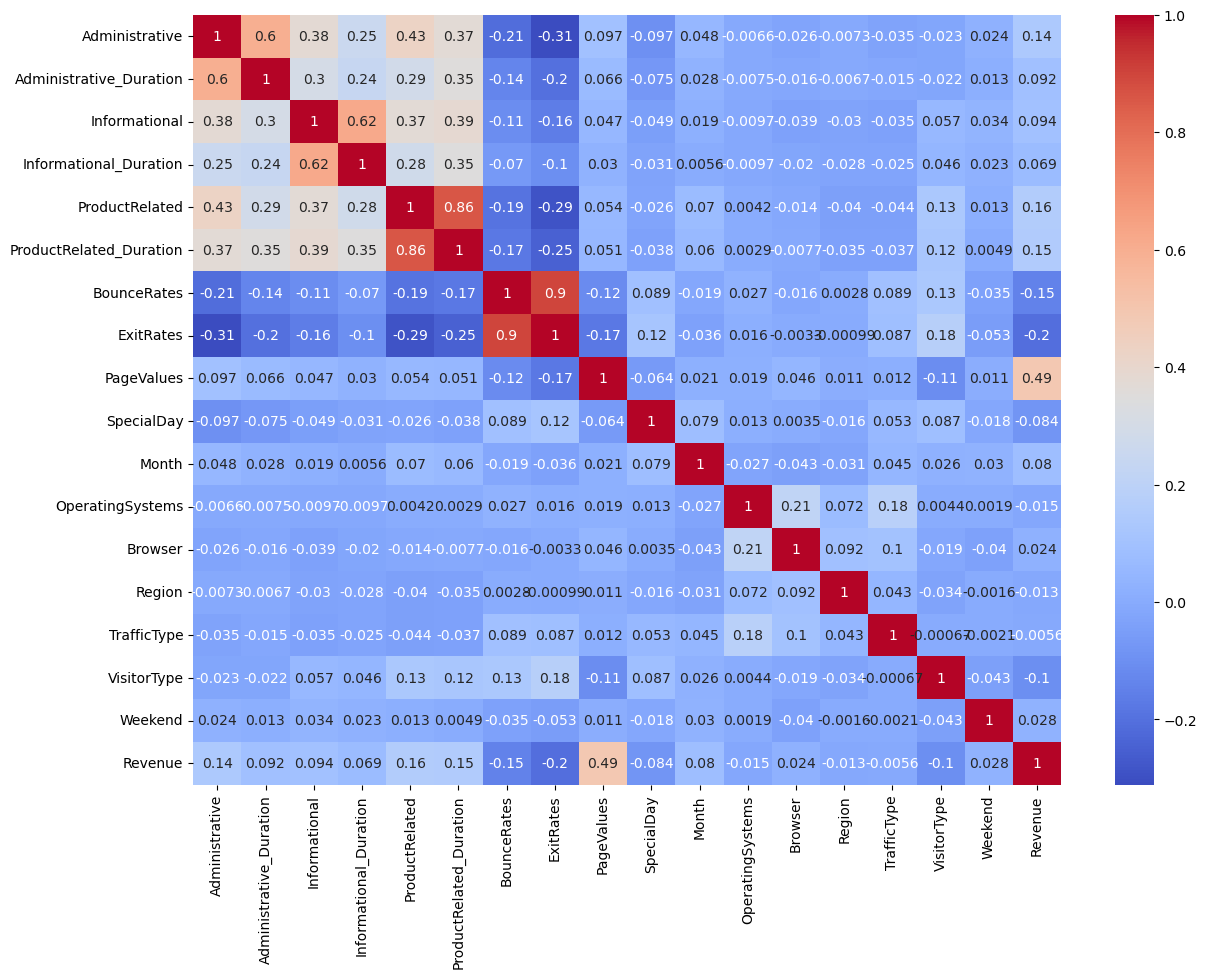

In [77]:
plt.figure(figsize = (14,10))

sns.heatmap(
    df.corr(),
    cmap = "coolwarm",
    annot = True
)

plt.show()

## Feature & Target Split

In [78]:
X = df.drop("Revenue", axis = 1)

y = df["Revenue"]

In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y                   # Maintains class ratio. => Before 84% No Purchase ,16% Purchase ; After split:Same ratio maintained
)

## Build Baseline Decision Tree

In [80]:
dt = DecisionTreeClassifier(
    random_state = 42,
    class_weight = "balanced"
)

dt.fit(X_train , y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [81]:
y_pred = dt.predict(X_test)

## Evaluate Model

In [87]:
print("Confusion Matrix :")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix :
[[1897  162]
 [ 169  213]]


In [89]:
print("Classification Report:")
print( classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      2059
           1       0.57      0.56      0.56       382

    accuracy                           0.86      2441
   macro avg       0.74      0.74      0.74      2441
weighted avg       0.86      0.86      0.86      2441



In [90]:
print(
    "F1 Score:",
    f1_score(y_test,pred)
)

F1 Score: 0.5627476882430648


In [91]:
# BenchMark is not acheived need improvment => Pruning (without pruning the DT is get overfit and it give good aacuracy for training data and poor accuracy for testing data)

## Pre-Pruning

In [94]:
dt = DecisionTreeClassifier(
    max_depth = 5,
    min_samples_leaf = 10,
    min_samples_split = 20,
    class_weight = "balanced",
    random_state = 42
    
)

## Hyper Parameter Tunning

In [99]:
depth = [5,7,8,10,15]

for d in depth :
    model = DecisionTreeClassifier(
        max_depth = d,
        class_weight = "balanced",
        random_state = 42
    )

    model.fit(X_train,y_train)

    y_pred = model.predict(X_test)

    score = f1_score(y_test,y_pred)

    print(f"for d = {d} : score is {score}")
    

for d = 5 : score is 0.6389157792836399
for d = 7 : score is 0.6336633663366337
for d = 8 : score is 0.6303664921465969
for d = 10 : score is 0.5854657113613101
for d = 15 : score is 0.565483476132191


## Cost Complexity Pruning

In [101]:
path = dt.cost_complexity_pruning_path(
    X_train,
    y_train
)

ccp_alphas = path.ccp_alphas

In [102]:
f1_scores = []

for alpha in ccp_alphas:

    model = DecisionTreeClassifier(
        ccp_alpha=alpha,
        class_weight='balanced',
        random_state=42
    )

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    f1_scores.append(
        f1_score(y_test,pred)
    )

In [103]:
best_alpha = ccp_alphas[
    np.argmax(f1_scores)
]

print(best_alpha)

0.0242325708731031


## : Final Model

In [104]:
final_model = DecisionTreeClassifier(
    ccp_alpha=best_alpha,
    class_weight='balanced',
    random_state=42
)

final_model.fit(X_train,y_train)

final_pred = final_model.predict(X_test)

In [105]:
print(
    classification_report(
        y_test,
        final_pred
    )
)

print(
    "Final F1:",
    f1_score(
        y_test,
        final_pred
    )
)                                     # F1 ≥ 0.55

              precision    recall  f1-score   support

           0       0.96      0.89      0.92      2059
           1       0.57      0.81      0.67       382

    accuracy                           0.88      2441
   macro avg       0.77      0.85      0.80      2441
weighted avg       0.90      0.88      0.88      2441

Final F1: 0.6702702702702703
